# 01 Arrays and Dimensions: From numpy to xarray
**Tutorial:** Building Geospatial Data Cubes for Earth Data Science  
**Focus:** Pine Ridge (Oglala Lakota), South Dakota  
**Prerequisites:** Notebook 00  

## What This Notebook Covers
Everything in a data cube is built on arrays. Before we work with real
satellite data, we need to understand:

1. What arrays are and how dimensions work
2. Why labeled arrays (xarray) are better than unlabeled ones (numpy)
   for Earth science data
3. How to build a simple 3D spatial cube from scratch

All examples in this notebook use Pine Ridge as the spatial context,
with synthetic data so we can focus on the concepts.

## Part 1: Arrays and Dimensions

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 1D array: a list of values with no spatial meaning
temps_1d = np.array([28.5, 32.1, 45.3, 58.2, 67.4, 78.9,
                     85.1, 83.6, 72.4, 58.0, 41.2, 30.1])

print("1D array with 12 monthly temperatures (°F):")
print(temps_1d)
print(f"Shape: {temps_1d.shape}  one dimension with 12 elements")
print(f"January temperature: {temps_1d[0]}°F  (position 0)")
print(f"July temperature:    {temps_1d[6]}°F  (position 6- remember this)")

1D array with 12 monthly temperatures (°F):
[28.5 32.1 45.3 58.2 67.4 78.9 85.1 83.6 72.4 58.  41.2 30.1]
Shape: (12,)  one dimension with 12 elements
January temperature: 28.5°F  (position 0)
July temperature:    85.1°F  (position 6- remember this)


In [2]:
# 2D array: add a spatial dimension
# Imagine a 4×4 grid of pixels covering a small area of Pine Ridge
# Each value is NDVI for one month

np.random.seed(0)
ndvi_2d = np.random.uniform(0.2, 0.6, size=(4, 4))

print("2D array with 4×4 NDVI grid (one time step):")
print(ndvi_2d.round(3))
print(f"\nShape: {ndvi_2d.shape}  rows=latitude, columns=longitude")
print("But which row is which latitude? We don't know without extra information.")

2D array with 4×4 NDVI grid (one time step):
[[0.42  0.486 0.441 0.418]
 [0.369 0.458 0.375 0.557]
 [0.585 0.353 0.517 0.412]
 [0.427 0.57  0.228 0.235]]

Shape: (4, 4)  rows=latitude, columns=longitude
But which row is which latitude? We don't know without extra information.


In [3]:
# 3D array: add the time dimension
# Now imagine 12 months of observations on that same 4×4 grid

ndvi_3d = np.random.uniform(0.1, 0.7, size=(12, 4, 4))
# Add a seasonal pattern (hint: NDVI peaks in summer)
seasonal = np.sin(np.arange(12) * np.pi / 6 - np.pi/3) * 0.2
ndvi_3d += seasonal[:, np.newaxis, np.newaxis]
ndvi_3d = ndvi_3d.clip(0.05, 0.85)

print("3D array = 12 months × 4 rows × 4 columns:")
print(f"Shape: {ndvi_3d.shape}")
print(f"\nThis is a data cube. But there's a problem:")
print(f"  ndvi_3d[6, 2, 1] = {ndvi_3d[6, 2, 1]:.3f}")
print(f"  What month is index 6? What latitude is row 2? What longitude is column 1?")
print(f"  We have to remember, or look it up somewhere else.")

3D array = 12 months × 4 rows × 4 columns:
Shape: (12, 4, 4)

This is a data cube. But there's a problem:
  ndvi_3d[6, 2, 1] = 0.574
  What month is index 6? What latitude is row 2? What longitude is column 1?
  We have to remember, or look it up somewhere else.


## Part 2: Why Labels Matter: Introducing xarray
xarray solves the labeling problem. Instead of remembering that index 6
is July and row 2 is latitude 43.25°N, you attach those labels directly
to the array.

In [4]:
# Define real coordinates for our 4×4 Pine Ridge grid
# A small area centered on Pine Ridge (43.0–43.75°N, 102.5–101.75°W)

lats   = np.array([43.0, 43.25, 43.5, 43.75])   # 4 latitude steps
lons   = np.array([-102.5, -102.25, -102.0, -101.75])  # 4 longitude steps
months = pd.date_range("2023-01-01", periods=12, freq="MS")

# Build the labeled DataArray
ndvi_da = xr.DataArray(
    data   = ndvi_3d,
    coords = {
        "time": months,      # name values for the time dimension
        "lat":  lats,        # name values for the latitude dimension
        "lon":  lons,        # name values for the longitude dimension
    },
    dims   = ["time", "lat", "lon"],  # order matches array shape (12, 4, 4)
    name   = "ndvi",
    attrs  = {
        "long_name":   "Normalized Difference Vegetation Index",
        "units":       "dimensionless",
        "valid_range": [0, 1],
        "location":    "Pine Ridge, Oglala Lakota Nation",
        "source":      "Synthetic data for illustration only",
    }
)

print(ndvi_da)

<xarray.DataArray 'ndvi' (time: 12, lat: 4, lon: 4)> Size: 2kB
array([[[0.05      , 0.42636683, 0.39368897, 0.44880221],
        [0.51396592, 0.40629006, 0.20368254, 0.39511243],
        [0.05      , 0.31074753, 0.05      , 0.49359627],
        [0.23990391, 0.17559208, 0.08552829, 0.39133513]],

       [[0.2736902 , 0.34106037, 0.05      , 0.3705813 ],
        [0.36725743, 0.3701604 , 0.56624885, 0.40909218],
        [0.21570474, 0.26221917, 0.41857872, 0.05      ],
        [0.40006003, 0.40238272, 0.12622954, 0.07735578]],

       [[0.28925701, 0.31822646, 0.44211806, 0.36316091],
        [0.6930243 , 0.16122689, 0.22532605, 0.19678571],
        [0.491865  , 0.25197496, 0.37978646, 0.24665536],
        [0.19538175, 0.16622508, 0.49379775, 0.18290977]],

       [[0.31794942, 0.4212351 , 0.69259594, 0.25826077],
        [0.70276694, 0.25765904, 0.78587568, 0.48119072],
        [0.78605665, 0.56290731, 0.64355815, 0.22351268],
        [0.36968418, 0.27211794, 0.37768412, 0.27123663]],

.

In [5]:
# Now selection is by meaning, not by position

# Select July (month 7) readable and unambiguous
july = ndvi_da.sel(time="2023-07-01")
print("July 2023 NDVI grid:")
print(july.values.round(3))
print(f"\nShape: {july.shape} one snapshot in time, still has lat/lon dimensions")

July 2023 NDVI grid:
[[0.693 0.452 0.761 0.511]
 [0.802 0.622 0.802 0.689]
 [0.708 0.574 0.847 0.66 ]
 [0.528 0.637 0.285 0.454]]

Shape: (4, 4) one snapshot in time, still has lat/lon dimensions


In [6]:
# Select a single location (the nearest point to 43.3°N, 102.1°W)
point_series = ndvi_da.sel(lat=43.3, lon=-102.1, method="nearest")
print("Time series for one location (nearest to 43.3°N, 102.1°W):")
for t, v in zip(point_series.time.values, point_series.values):
    print(f"  {str(t)[:7]}: NDVI = {v:.3f}")

Time series for one location (nearest to 43.3°N, 102.1°W):
  2023-01: NDVI = 0.204
  2023-02: NDVI = 0.566
  2023-03: NDVI = 0.225
  2023-04: NDVI = 0.786
  2023-05: NDVI = 0.587
  2023-06: NDVI = 0.741
  2023-07: NDVI = 0.802
  2023-08: NDVI = 0.542
  2023-09: NDVI = 0.190
  2023-10: NDVI = 0.050
  2023-11: NDVI = 0.273
  2023-12: NDVI = 0.050


In [13]:
# Aggregation operations work along named dimensions

# Spatial mean: average NDVI across all pixels for each time step
spatial_mean = ndvi_da.mean(dim=["lat", "lon"])
print("Spatial mean NDVI (averaged over all pixels) by month:")
print(spatial_mean.round(3).values)

# Annual mean: average over all time steps
annual_mean = ndvi_da.mean(dim="time")
print(f"\nAnnual mean NDVI grid shape: {annual_mean.shape}")
print("(Still has lat/lon because we only averaged along time)")

Spatial mean NDVI (averaged over all pixels) by month:
[0.29  0.294 0.319 0.464 0.526 0.617 0.627 0.519 0.432 0.293 0.232 0.158]

Annual mean NDVI grid shape: (4, 4)
(Still has lat/lon because we only averaged along time)


## Part 3: Building a Multi-Variable Dataset
A single DataArray holds one variable. A Dataset holds multiple variables
that share coordinates. This is the full data cube.

In [8]:
# Create a second variable: temperature
# (Same grid, same time steps and they share coordinates)

temp_3d = np.random.uniform(20, 90, size=(12, 4, 4))
seasonal_temp = np.sin(np.arange(12) * np.pi / 6 - np.pi/2) * 30 + 55
temp_3d += seasonal_temp[:, np.newaxis, np.newaxis]

temp_da = xr.DataArray(
    data   = temp_3d,
    coords = {"time": months, "lat": lats, "lon": lons},
    dims   = ["time", "lat", "lon"],
    name   = "tmax_f",
    attrs  = {
        "long_name": "Maximum daily temperature",
        "units":     "degrees Fahrenheit",
    }
)

# Combine into a Dataset
cube = xr.Dataset(
    data_vars = {
        "ndvi":   ndvi_da,
        "tmax_f": temp_da,
    },
    attrs = {
        "title":       "Pine Ridge Environmental Data Cube",
        "location":    "Pine Ridge, Oglala Lakota Nation",
        "crs":         "EPSG:4326 (WGS84 geographic)",
        "source":      "Synthetic data for illustration only",
        "created_by":  "tribal_datacube_tutorial notebook 01",
    }
)

print(cube)

<xarray.Dataset> Size: 3kB
Dimensions:  (time: 12, lat: 4, lon: 4)
Coordinates:
  * time     (time) datetime64[us] 96B 2023-01-01 2023-02-01 ... 2023-12-01
  * lat      (lat) float64 32B 43.0 43.25 43.5 43.75
  * lon      (lon) float64 32B -102.5 -102.2 -102.0 -101.8
Data variables:
    ndvi     (time, lat, lon) float64 2kB 0.05 0.4264 0.3937 ... 0.3076 0.1722
    tmax_f   (time, lat, lon) float64 2kB 82.56 107.8 114.3 ... 50.16 61.99
Attributes:
    title:       Pine Ridge Environmental Data Cube
    location:    Pine Ridge, Oglala Lakota Nation
    crs:         EPSG:4326 (WGS84 geographic)
    source:      Synthetic data for illustration only
    created_by:  tribal_datacube_tutorial notebook 01


In [9]:
# With a Dataset, you can ask multi-variable questions

# What was the mean NDVI during months where temperature exceeded 80°F?
hot_months = cube.where(cube["tmax_f"] > 80)
hot_ndvi   = hot_months["ndvi"].mean(skipna=True)
cool_ndvi  = cube.where(cube["tmax_f"] <= 80)["ndvi"].mean(skipna=True)

print(f"Mean NDVI during hot months (tmax > 80°F): {float(hot_ndvi):.3f}")
print(f"Mean NDVI during cool months (tmax ≤ 80°F): {float(cool_ndvi):.3f}")
print()
print("Higher NDVI in hot months makes sense for")
print("grass growth in the Great Plains. But during a drought year,")
print("NDVI would stay low even in hot months. That's the pattern")
print("we'll look for in real data starting in notebook 03.")

Mean NDVI during hot months (tmax > 80°F): 0.428
Mean NDVI during cool months (tmax ≤ 80°F): 0.255

Higher NDVI in hot months makes sense for
grass growth in the Great Plains. But during a drought year,
NDVI would stay low even in hot months. That's the pattern
we'll look for in real data starting in notebook 03.


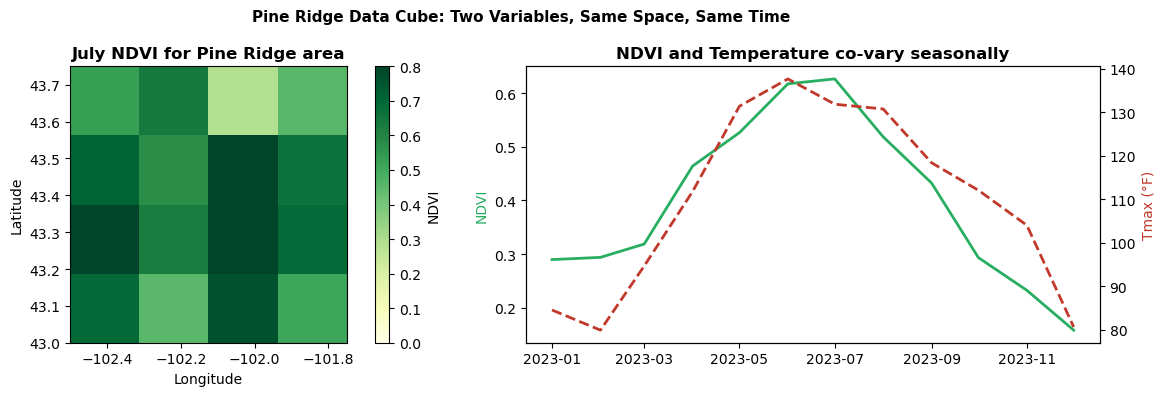

In [14]:
# Visualize both variables together

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Map of mean NDVI for July
july_ndvi = cube["ndvi"].sel(time="2023-07-01")
im1 = axes[0].imshow(
    july_ndvi.values,
    origin="lower",
    extent=[lons.min(), lons.max(), lats.min(), lats.max()],
    cmap="YlGn", vmin=0, vmax=0.8,
)
plt.colorbar(im1, ax=axes[0], label="NDVI")
axes[0].set_title("July NDVI for Pine Ridge area", fontweight="bold")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# Time series of spatial mean NDVI vs temperature
ax2 = axes[1]
ax3 = ax2.twinx()

spatial_ndvi = cube["ndvi"].mean(dim=["lat", "lon"])
spatial_temp = cube["tmax_f"].mean(dim=["lat", "lon"])

ax2.plot(months, spatial_ndvi.values, color="#27AE60", linewidth=2, label="NDVI")
ax3.plot(months, spatial_temp.values, color="#C0392B", linewidth=2,
         linestyle="--", label="Tmax (°F)")

ax2.set_ylabel("NDVI", color="#27AE60")
ax3.set_ylabel("Tmax (°F)", color="#C0392B")
axes[1].set_title("NDVI and Temperature co-vary seasonally", fontweight="bold")
plt.xticks(rotation=30)

plt.suptitle(
    "Pine Ridge Data Cube: Two Variables, Same Space, Same Time",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()

## Part 4: Saving and Loading a Cube
Data cubes are saved as NetCDF (`.nc`) files, which is the standard format for
scientific array data. xarray reads and writes NetCDF natively.

In [11]:
from pathlib import Path

# Save the cube to a NetCDF file
output_dir = Path("../data")
output_dir.mkdir(exist_ok=True)

save_path = output_dir/"pine_ridge_example_cube.nc"
cube.to_netcdf(save_path)
print(f"Cube saved to: {save_path}")
print(f"File size: {save_path.stat().st_size / 1024:.1f} KB")

Cube saved to: ..\data\pine_ridge_example_cube.nc
File size: 11.9 KB


In [12]:
# Load it back so metadata is preserved
loaded = xr.open_dataset(save_path)
print("Loaded from disk:")
print(loaded)
print("\nAttributes preserved:")
for k, v in loaded.attrs.items():
    print(f"  {k}: {v}")

Loaded from disk:
<xarray.Dataset> Size: 3kB
Dimensions:  (time: 12, lat: 4, lon: 4)
Coordinates:
  * time     (time) datetime64[ns] 96B 2023-01-01 2023-02-01 ... 2023-12-01
  * lat      (lat) float64 32B 43.0 43.25 43.5 43.75
  * lon      (lon) float64 32B -102.5 -102.2 -102.0 -101.8
Data variables:
    ndvi     (time, lat, lon) float64 2kB ...
    tmax_f   (time, lat, lon) float64 2kB ...
Attributes:
    title:       Pine Ridge Environmental Data Cube
    location:    Pine Ridge, Oglala Lakota Nation
    crs:         EPSG:4326 (WGS84 geographic)
    source:      Synthetic data for illustration only
    created_by:  tribal_datacube_tutorial notebook 01

Attributes preserved:
  title: Pine Ridge Environmental Data Cube
  location: Pine Ridge, Oglala Lakota Nation
  crs: EPSG:4326 (WGS84 geographic)
  source: Synthetic data for illustration only
  created_by: tribal_datacube_tutorial notebook 01


---

## Summary: What You Learned
| Concept | What it means |
|---|---|
| **Array** | A grid of numbers; the fundamental data structure |
| **Dimension** | An axis of an array (time, lat, lon) |
| **Coordinate** | The actual values along a dimension (dates, degrees) |
| **DataArray** | A labeled numpy array with one variable |
| **Dataset** | A collection of DataArrays sharing coordinates creating a data cube |
| **Attribute** | Metadata attached to a DataArray or Dataset |
| **NetCDF** | The file format for saving and loading data cubes |

## Discussion Questions
1. What dimensions would you need for a data cube that includes
   multiple Tribal Nations (not just Pine Ridge)? How would you add
   that dimension to the cube we built here?

2. What metadata attributes would you want to include in a data cube
   built from real data about Pine Ridge? Think about both technical
   metadata (CRS, resolution) and governance metadata (who owns the data,
   what label it carries).

3. How is a NetCDF file different from a CSV file? When would you use
   each one?

## Next Notebook
**02 Your First Data Cube:** We replace the synthetic data with real
MODIS NDVI observations over Pine Ridge, fetch them via the ORNL DAAC
API, and build a proper time series data cube.